MODEL TRAINING AND EVALUATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [4]:
dfd = pd.read_csv("/content/day (1).csv")
dfh = pd.read_csv("/content/hour.csv")
dfd.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
# Columns you already removed earlier:
cols_to_drop = ['instant', 'dteday', 'casual', 'registered', 'yr']

for col in cols_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df.head()


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,1,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,1,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,1,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [6]:
df.isnull().sum()
df.dropna(inplace=True)


In [7]:
X = df.drop('cnt', axis=1)
y = df['cnt']


In [10]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X, y, test_size=0.2, random_state=42)
lr_day = LinearRegression()
lr_day.fit(X_train_d, y_train_d)

pred_lr_day = lr_day.predict(X_test_d)

print("DAY-WISE Linear Regression")
print("R2 Score:", r2_score(y_test_d, pred_lr_day))
print("RMSE:", np.sqrt(mean_squared_error(y_test_d, pred_lr_day)))
print("MAE:", mean_absolute_error(y_test_d, pred_lr_day))

DAY-WISE Linear Regression
R2 Score: 0.5518626278474863
RMSE: 1340.5141220616438
MAE: 1143.3937178558917


In [11]:
rf_day = RandomForestRegressor(n_estimators=200, random_state=42)
rf_day.fit(X_train_d, y_train_d)

pred_rf_day = rf_day.predict(X_test_d)

print("\nDAY-WISE Random Forest")
print("R2 Score:", r2_score(y_test_d, pred_rf_day))
print("RMSE:", np.sqrt(mean_squared_error(y_test_d, pred_rf_day)))
print("MAE:", mean_absolute_error(y_test_d, pred_rf_day))



DAY-WISE Random Forest
R2 Score: 0.5811127837770522
RMSE: 1296.0279430808691
MAE: 1079.4135714285712


In [13]:
df_hour = dfh.copy()

# Columns to drop for the hour-wise data
cols_to_drop_h = ['instant', 'dteday', 'casual', 'registered', 'yr']

for col in cols_to_drop_h:
    if col in df_hour.columns:
        df_hour.drop(col, axis=1, inplace=True)

# Handle missing values (if any, as was done for dfd)
df_hour.dropna(inplace=True)

# Prepare features (X_h) and target (y_h) for hour-wise prediction
X_h = df_hour.drop('cnt', axis=1)
y_h = df_hour['cnt']

# Split hour-wise data into training and testing sets
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

lr_hour = LinearRegression()
lr_hour.fit(X_train_h, y_train_h)

pred_lr_hour = lr_hour.predict(X_test_h)

print("\nHOUR-WISE Linear Regression")
print("R2 Score:", r2_score(y_test_h, pred_lr_hour))
print("RMSE:", np.sqrt(mean_squared_error(y_test_h, pred_lr_hour)))
print("MAE:", mean_absolute_error(y_test_h, pred_lr_hour))


HOUR-WISE Linear Regression
R2 Score: 0.3455468386885291
RMSE: 143.95668985278937
MAE: 106.75474199169594


In [14]:
rf_hour = RandomForestRegressor(n_estimators=200, random_state=42)
rf_hour.fit(X_train_h, y_train_h)

pred_rf_hour = rf_hour.predict(X_test_h)

print("\nHOUR-WISE Random Forest")
print("R2 Score:", r2_score(y_test_h, pred_rf_hour))
print("RMSE:", np.sqrt(mean_squared_error(y_test_h, pred_rf_hour)))
print("MAE:", mean_absolute_error(y_test_h, pred_rf_hour))



HOUR-WISE Random Forest
R2 Score: 0.8664803681074333
RMSE: 65.02271960915206
MAE: 42.210786440352905


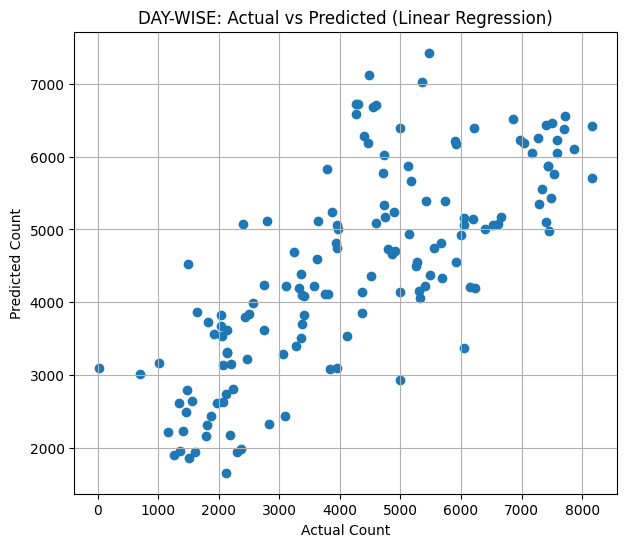

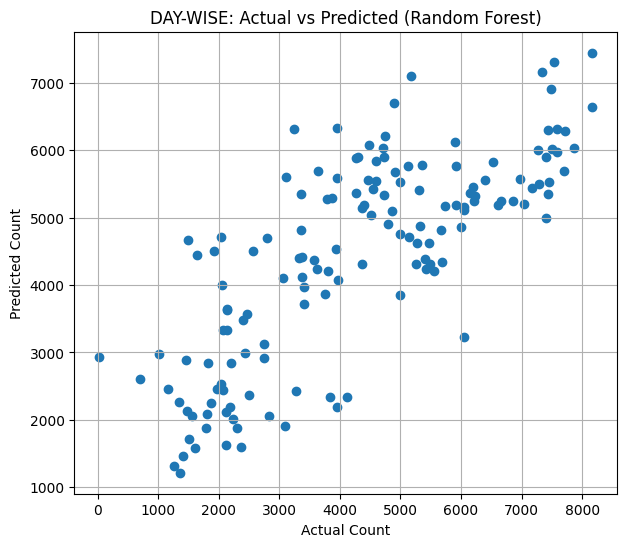

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test_d, pred_lr_day)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("DAY-WISE: Actual vs Predicted (Linear Regression)")
plt.grid(True)
plt.show()
plt.figure(figsize=(7,6))
plt.scatter(y_test_d, pred_rf_day)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("DAY-WISE: Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.show()


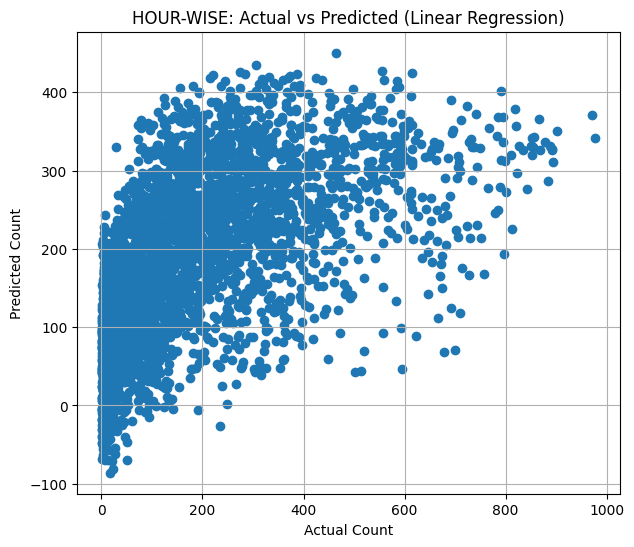

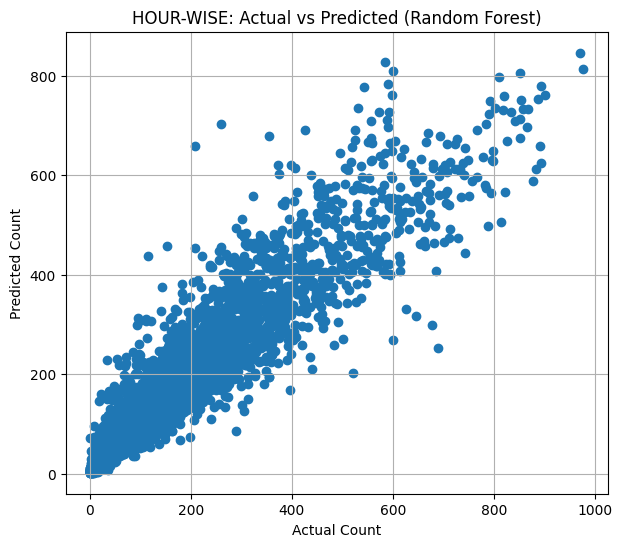

In [16]:
plt.figure(figsize=(7,6))
plt.scatter(y_test_h, pred_lr_hour)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("HOUR-WISE: Actual vs Predicted (Linear Regression)")
plt.grid(True)
plt.show()
plt.figure(figsize=(7,6))
plt.scatter(y_test_h, pred_rf_hour)
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.title("HOUR-WISE: Actual vs Predicted (Random Forest)")
plt.grid(True)
plt.show()


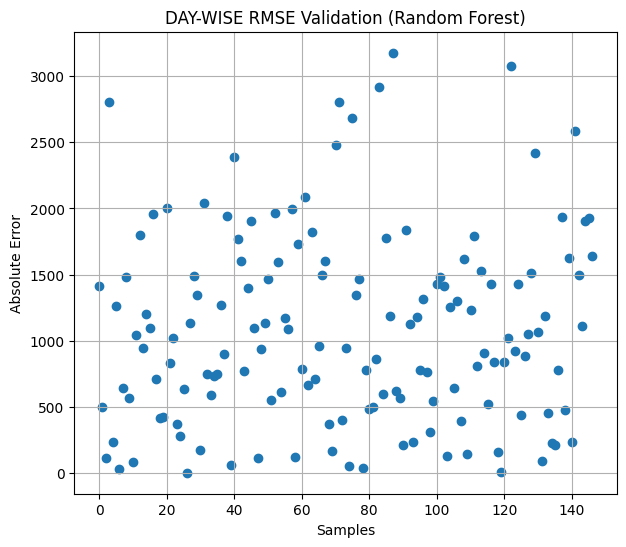

In [17]:
errors_day = abs(y_test_d - pred_rf_day)

plt.figure(figsize=(7,6))
plt.scatter(range(len(errors_day)), errors_day)
plt.xlabel("Samples")
plt.ylabel("Absolute Error")
plt.title("DAY-WISE RMSE Validation (Random Forest)")
plt.grid(True)
plt.show()


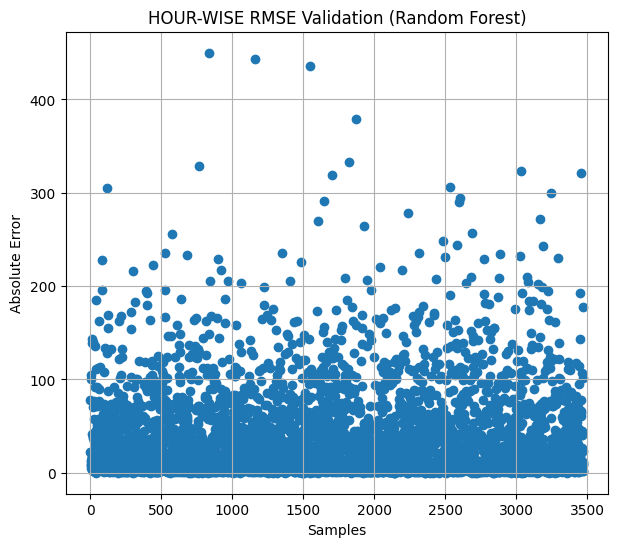

In [18]:
errors_hour = abs(y_test_h - pred_rf_hour)

plt.figure(figsize=(7,6))
plt.scatter(range(len(errors_hour)), errors_hour)
plt.xlabel("Samples")
plt.ylabel("Absolute Error")
plt.title("HOUR-WISE RMSE Validation (Random Forest)")
plt.grid(True)
plt.show()


In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_day = np.sqrt(mean_squared_error(y_test_d, pred_rf_day))
rmse_day


np.float64(1296.0279430808691)

In [20]:
rmse_hour = np.sqrt(mean_squared_error(y_test_h, pred_rf_hour))
rmse_hour


np.float64(65.02271960915206)

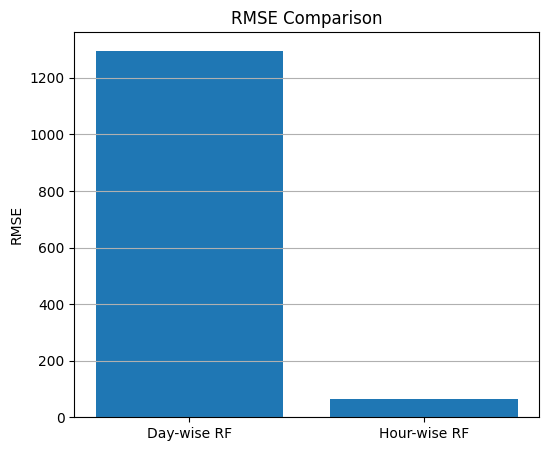

In [21]:
plt.figure(figsize=(6,5))
models = ["Day-wise RF", "Hour-wise RF"]
rmse_values = [rmse_day, rmse_hour]

plt.bar(models, rmse_values)
plt.ylabel("RMSE")
plt.title("RMSE Comparison")
plt.grid(axis='y')
plt.show()


FEATURE IMPORTANCE

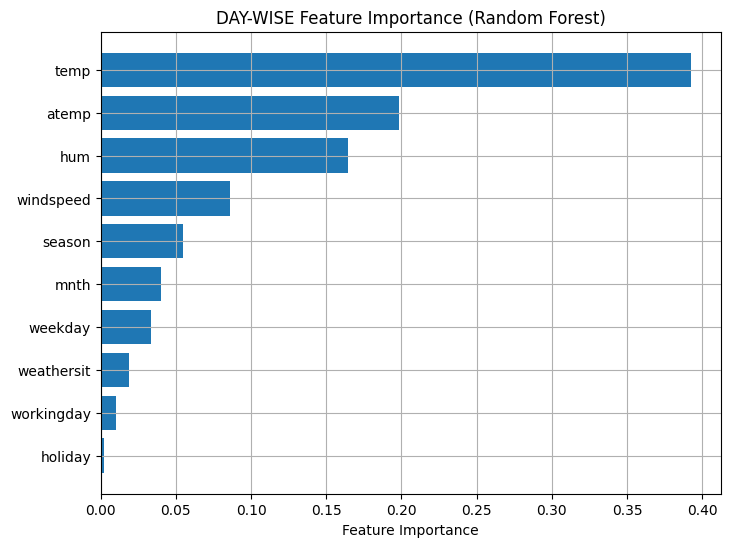

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance values
importances_day = rf_day.feature_importances_
feature_names_day = X.columns

# Create DataFrame
fi_day = pd.DataFrame({
    'Feature': feature_names_day,
    'Importance': importances_day
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(fi_day['Feature'], fi_day['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("DAY-WISE Feature Importance (Random Forest)")
plt.grid(True)
plt.show()

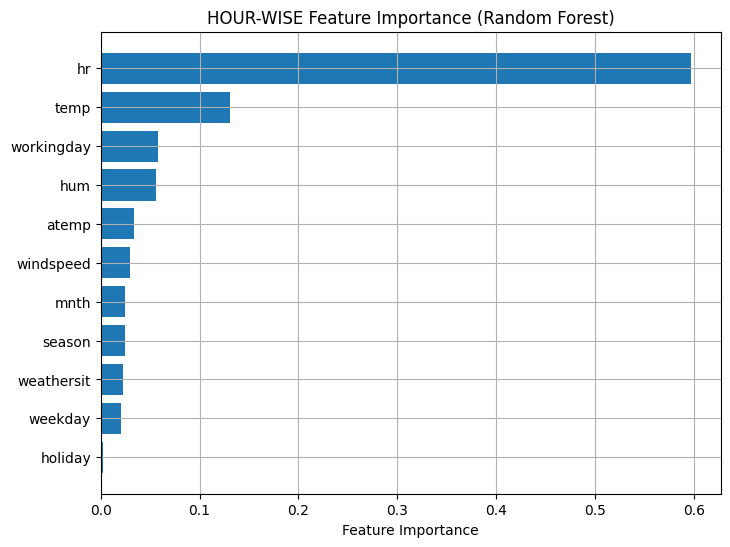

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance values
importances_hour = rf_hour.feature_importances_
feature_names_hour = X_h.columns

# Create DataFrame
fi_hour = pd.DataFrame({
    'Feature': feature_names_hour,
    'Importance': importances_hour
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,6))
plt.barh(fi_hour['Feature'], fi_hour['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("HOUR-WISE Feature Importance (Random Forest)")
plt.grid(True)
plt.show()

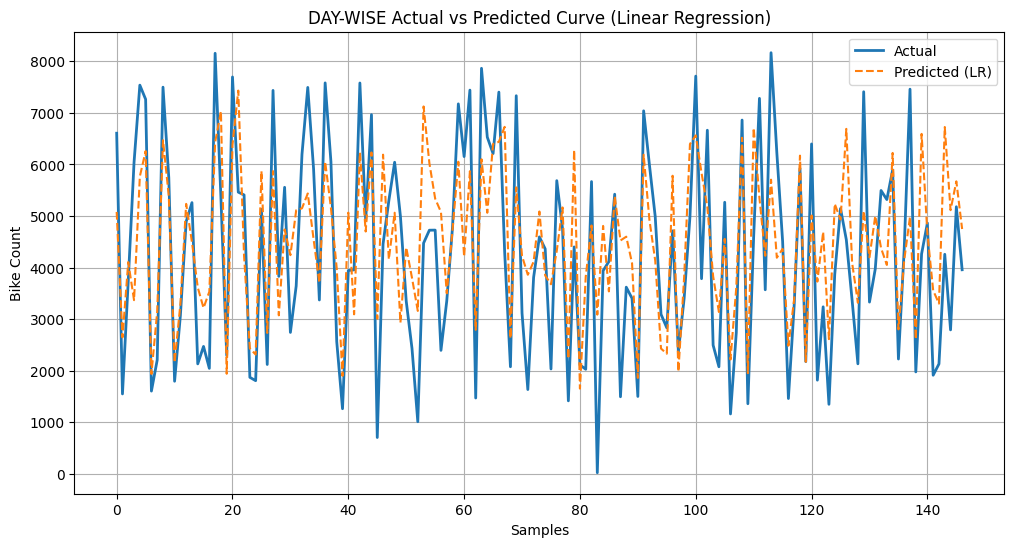

In [26]:
plt.figure(figsize=(12,6))
plt.plot(y_test_d.values, label="Actual", linewidth=2)
plt.plot(pred_lr_day, label="Predicted (LR)", linestyle='dashed')
plt.xlabel("Samples")
plt.ylabel("Bike Count")
plt.title("DAY-WISE Actual vs Predicted Curve (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()


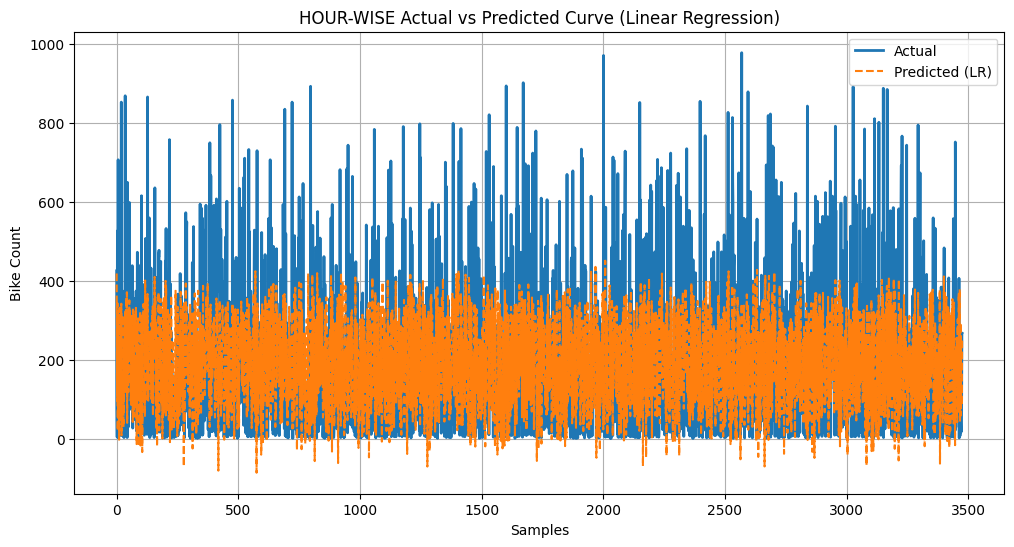

In [27]:
plt.figure(figsize=(12,6))
plt.plot(y_test_h.values, label="Actual", linewidth=2)
plt.plot(pred_lr_hour, label="Predicted (LR)", linestyle='dashed')
plt.xlabel("Samples")
plt.ylabel("Bike Count")
plt.title("HOUR-WISE Actual vs Predicted Curve (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()
